In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix

### Reproducibility

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


### CLASS NAMES for FashionMNIST

In [ ]:
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

## TASK 1 - Data Exploration and Preprocessing

In [ ]:
# 1. Normalise: mean=0.5, std=0.5 (maps [0,1] → [-1,1])
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
# 2. Download / load
full_train = datasets.FashionMNIST(root="./data", train=True,
                                   download=True, transform=transform)
test_set   = datasets.FashionMNIST(root="./data", train=False,
                                   download=True, transform=transform)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.7MB/s]


In [ ]:
# 3. Split train → 80 % train / 20 % validation
val_size   = int(0.2 * len(full_train))
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size])

In [ ]:
# 4. DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# 5. Print shapes
sample_images, sample_labels = next(iter(train_loader))
print("=" * 55)
print("Dataset shapes")
print("=" * 55)
print(f"  Training samples  : {len(train_set)}")
print(f"  Validation samples: {len(val_set)}")
print(f"  Test samples      : {len(test_set)}")
print(f"\nSingle batch tensor shape: {sample_images.shape}")
print("  Dimension 0 – Batch size  (number of images per batch)")
print("  Dimension 1 – Channels    (1 = grayscale)")
print("  Dimension 2 – Height      (28 pixels)")
print("  Dimension 3 – Width       (28 pixels)")

Dataset shapes
  Training samples  : 48000
  Validation samples: 12000
  Test samples      : 10000

Single batch tensor shape: torch.Size([64, 1, 28, 28])
  Dimension 0 – Batch size  (number of images per batch)
  Dimension 1 – Channels    (1 = grayscale)
  Dimension 2 – Height      (28 pixels)
  Dimension 3 – Width       (28 pixels)


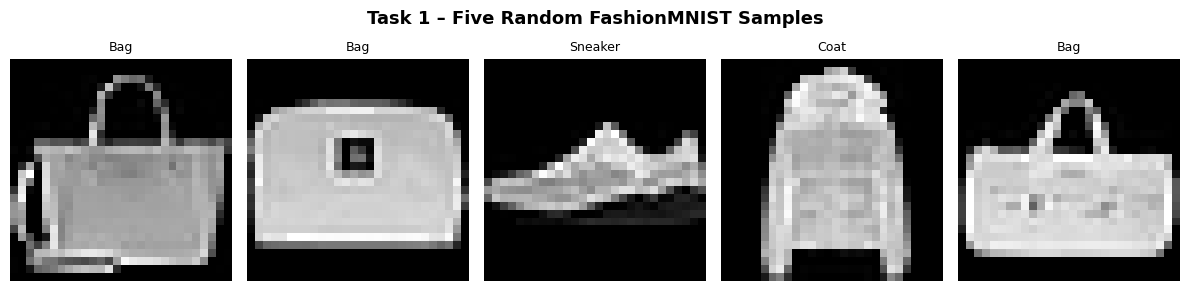

Saved: task1_sample_images.png


In [ ]:
# 6. Display 5 random images
indices = np.random.choice(len(full_train), 5, replace=False)
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle("Task 1 – Five Random FashionMNIST Samples", fontsize=13, fontweight="bold")
for ax, idx in zip(axes, indices):
    img, label = full_train[idx]
    img_np = img.squeeze().numpy() * 0.5 + 0.5      # de-normalise for display
    ax.imshow(img_np, cmap="gray")
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("task1_sample_images.png", dpi=120)
plt.show()
print("Saved: task1_sample_images.png")

### Helper functions used across multiple tasks


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    """Train a model and return history dict + total training time."""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    start = time.time()

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        running_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            X = X.view(X.size(0), -1)          # flatten 28×28 → 784
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        # ── Validate ──
        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                X = X.view(X.size(0), -1)
                out  = model(X)
                val_loss += criterion(out, y).item() * X.size(0)
                correct  += (out.argmax(1) == y).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc   = correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if epoch % 2 == 0 or epoch == 1:
            print(f"  Epoch {epoch:02d}/{epochs}  "
                  f"Train Loss: {train_loss:.4f}  "
                  f"Val Loss: {val_loss:.4f}  "
                  f"Val Acc: {val_acc:.4f}")

    elapsed = time.time() - start
    return history, elapsed


def evaluate_model(model, loader):
    """Return accuracy, all predictions, and all true labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE).view(X.size(0), -1)
            preds = model(X).argmax(1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(y.numpy())
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return acc, np.array(all_preds), np.array(all_labels)


def plot_loss_curves(histories, labels, title, filename):
    fig, axes = plt.subplots(1, len(histories), figsize=(5 * len(histories), 4))
    if len(histories) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for ax, hist, lbl in zip(axes, histories, labels):
        ax.plot(hist["train_loss"], label="Train Loss", linewidth=2)
        ax.plot(hist["val_loss"],   label="Val Loss",   linewidth=2, linestyle="--")
        ax.set_title(lbl)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=120)
    plt.show()
    print(f"Saved: {filename}")

## TASK 2 - Architecture Design Experiment


Task 2 – Training three architectures (10 epochs each)

── Model A (784→32→10)  (25,450 params) ──
  Epoch 01/10  Train Loss: 0.5657  Val Loss: 0.4647  Val Acc: 0.8371
  Epoch 02/10  Train Loss: 0.4260  Val Loss: 0.4147  Val Acc: 0.8547
  Epoch 04/10  Train Loss: 0.3665  Val Loss: 0.3802  Val Acc: 0.8661
  Epoch 06/10  Train Loss: 0.3367  Val Loss: 0.3666  Val Acc: 0.8693
  Epoch 08/10  Train Loss: 0.3168  Val Loss: 0.3681  Val Acc: 0.8683
  Epoch 10/10  Train Loss: 0.2995  Val Loss: 0.3564  Val Acc: 0.8746
  Test Accuracy: 0.8678  |  Time: 153.6s

── Model B (784→128→64→10)  (109,386 params) ──
  Epoch 01/10  Train Loss: 0.5413  Val Loss: 0.4231  Val Acc: 0.8502
  Epoch 02/10  Train Loss: 0.3891  Val Loss: 0.3785  Val Acc: 0.8610
  Epoch 04/10  Train Loss: 0.3245  Val Loss: 0.3451  Val Acc: 0.8749
  Epoch 06/10  Train Loss: 0.2869  Val Loss: 0.3370  Val Acc: 0.8788
  Epoch 08/10  Train Loss: 0.2638  Val Loss: 0.3232  Val Acc: 0.8852
  Epoch 10/10  Train Loss: 0.2418  Val Loss: 0.3384 

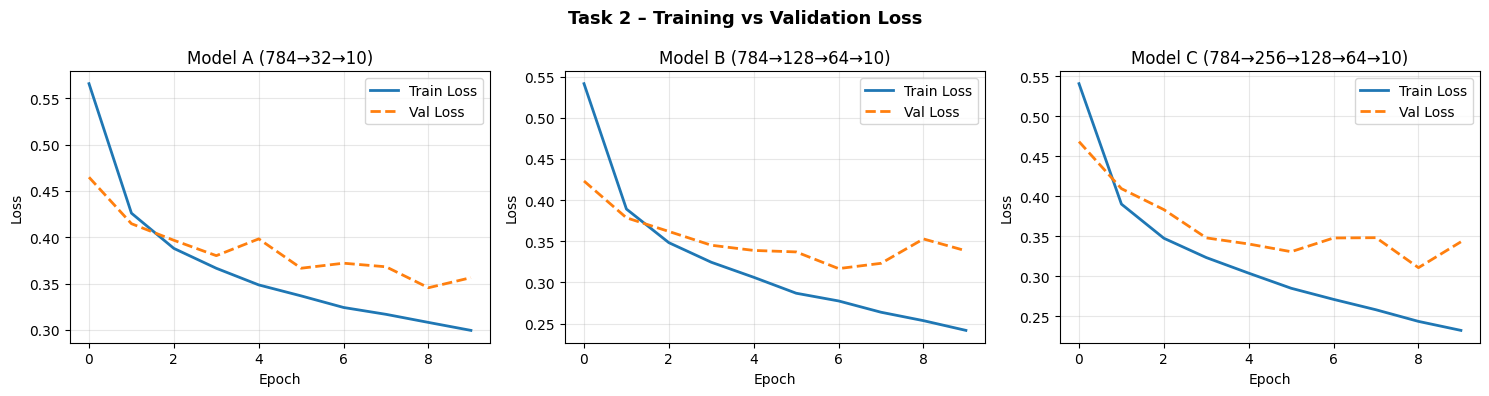

Saved: task2_loss_curves.png


In [ ]:
class ModelA(nn.Module):
    """Shallow: 784 → 32 → 10"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 32), nn.ReLU(),
            nn.Linear(32, 10)
        )
    def forward(self, x): return self.net(x)


class ModelB(nn.Module):
    """Medium: 784 → 128 → 64 → 10"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)


class ModelC(nn.Module):
    """Deep: 784 → 256 → 128 → 64 → 10"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)


print("Task 2 – Training three architectures (10 epochs each)")

t2_models   = [ModelA(), ModelB(), ModelC()]
t2_labels   = ["Model A (784→32→10)",
                "Model B (784→128→64→10)",
                "Model C (784→256→128→64→10)"]
t2_histories = []
t2_times     = []
t2_accs      = []

for mdl, lbl in zip(t2_models, t2_labels):
    print(f"\n── {lbl}  ({count_parameters(mdl):,} params) ──")
    hist, elapsed = train_model(mdl, train_loader, val_loader, epochs=10)
    t2_histories.append(hist)
    t2_times.append(elapsed)
    acc, _, _ = evaluate_model(mdl, test_loader)
    t2_accs.append(acc)
    print(f"  Test Accuracy: {acc:.4f}  |  Time: {elapsed:.1f}s")

# Best model index
best_idx = int(np.argmax(t2_accs))
best_model_t2 = t2_models[best_idx]
print(f"\nBest Task-2 model: {t2_labels[best_idx]}  "
      f"(Test Acc = {t2_accs[best_idx]:.4f})")

plot_loss_curves(t2_histories, t2_labels,
                 "Task 2 – Training vs Validation Loss",
                 "task2_loss_curves.png")

## TASK 3 - Underfitting vs Overfitting Analysis



── Tiny Model (3,190 params) ──
  Epoch 01/15  Train Loss: 1.2840  Val Loss: 0.8435  Val Acc: 0.7320
  Epoch 02/15  Train Loss: 0.7541  Val Loss: 0.7241  Val Acc: 0.7606
  Epoch 04/15  Train Loss: 0.6098  Val Loss: 0.6081  Val Acc: 0.8023
  Epoch 06/15  Train Loss: 0.5545  Val Loss: 0.5608  Val Acc: 0.8118
  Epoch 08/15  Train Loss: 0.5302  Val Loss: 0.5731  Val Acc: 0.8023
  Epoch 10/15  Train Loss: 0.5186  Val Loss: 0.5421  Val Acc: 0.8176
  Epoch 12/15  Train Loss: 0.5082  Val Loss: 0.5317  Val Acc: 0.8188
  Epoch 14/15  Train Loss: 0.5009  Val Loss: 0.5342  Val Acc: 0.8147

── Huge Model (1,764,426 params) ──
  Epoch 01/15  Train Loss: 0.6244  Val Loss: 0.4609  Val Acc: 0.8352
  Epoch 02/15  Train Loss: 0.4220  Val Loss: 0.4332  Val Acc: 0.8513
  Epoch 04/15  Train Loss: 0.3475  Val Loss: 0.3664  Val Acc: 0.8712
  Epoch 06/15  Train Loss: 0.3056  Val Loss: 0.3535  Val Acc: 0.8758
  Epoch 08/15  Train Loss: 0.2723  Val Loss: 0.3251  Val Acc: 0.8878
  Epoch 10/15  Train Loss: 0.2473

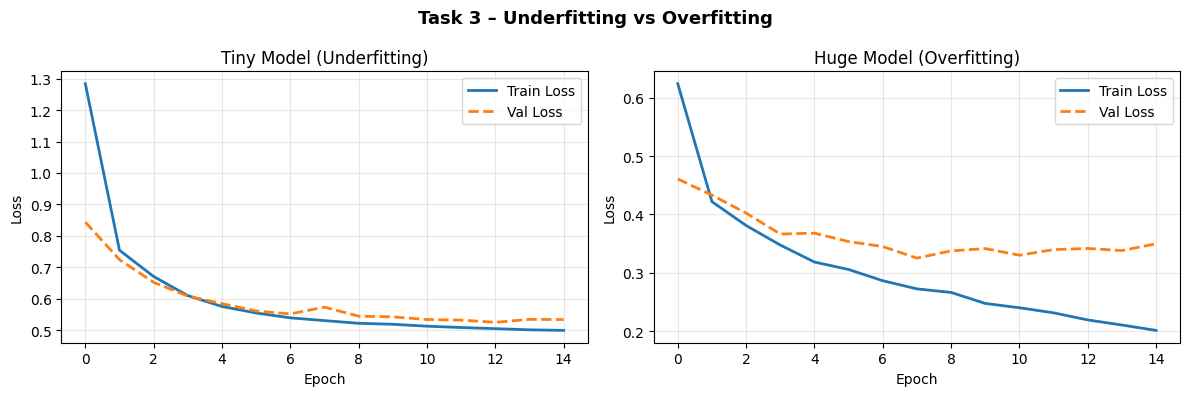

Saved: task3_overfit_underfit.png


In [ ]:
class TinyModel(nn.Module):
    """Very small – expected to underfit: 784 → 4 → 10"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 4), nn.ReLU(),
            nn.Linear(4, 10)
        )
    def forward(self, x): return self.net(x)


class HugeModel(nn.Module):
    """Very large – expected to overfit: 784→1024→512→512→256→128→64→10"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 512),  nn.ReLU(),
            nn.Linear(512, 256),  nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

tiny_model = TinyModel()
huge_model = HugeModel()

print(f"\n── Tiny Model ({count_parameters(tiny_model):,} params) ──")
hist_tiny, _ = train_model(tiny_model, train_loader, val_loader, epochs=15)

print(f"\n── Huge Model ({count_parameters(huge_model):,} params) ──")
hist_huge, _ = train_model(huge_model, train_loader, val_loader, epochs=15)

acc_tiny, _, _ = evaluate_model(tiny_model, test_loader)
acc_huge, _, _ = evaluate_model(huge_model, test_loader)
print(f"\nTiny Model Test Acc: {acc_tiny:.4f}")
print(f"Huge Model Test Acc: {acc_huge:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Task 3 – Underfitting vs Overfitting", fontsize=13, fontweight="bold")

for ax, hist, lbl in zip(axes,
                          [hist_tiny, hist_huge],
                          ["Tiny Model (Underfitting)", "Huge Model (Overfitting)"]):
    ax.plot(hist["train_loss"], label="Train Loss", linewidth=2)
    ax.plot(hist["val_loss"],   label="Val Loss",   linewidth=2, linestyle="--")
    ax.set_title(lbl)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task3_overfit_underfit.png", dpi=120)
plt.show()
print("Saved: task3_overfit_underfit.png")

## TASK 4 - Batch Normalization Study

Model C + BN  params: 243,658
Model C (orig) params: 242,762

── Model C with BatchNorm ──
  Epoch 01/10  Train Loss: 0.4977  Val Loss: 0.3717  Val Acc: 0.8671
  Epoch 02/10  Train Loss: 0.3547  Val Loss: 0.3307  Val Acc: 0.8795
  Epoch 04/10  Train Loss: 0.2887  Val Loss: 0.3149  Val Acc: 0.8847
  Epoch 06/10  Train Loss: 0.2513  Val Loss: 0.3207  Val Acc: 0.8850
  Epoch 08/10  Train Loss: 0.2206  Val Loss: 0.3144  Val Acc: 0.8892
  Epoch 10/10  Train Loss: 0.1980  Val Loss: 0.2959  Val Acc: 0.8956
Test Accuracy (with BN): 0.8914
Test Accuracy (without BN – Model C): 0.8739


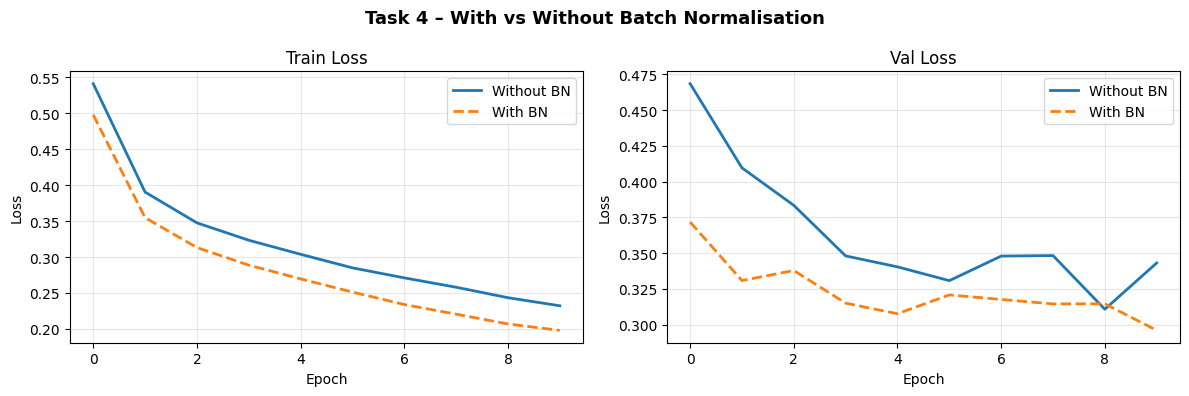

Saved: task4_batchnorm.png


In [ ]:
class ModelC_BN(nn.Module):
    """Model C with BatchNorm: Linear → BN → ReLU pattern"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

model_c_bn = ModelC_BN()
print(f"Model C + BN  params: {count_parameters(model_c_bn):,}")
print(f"Model C (orig) params: {count_parameters(ModelC()):,}")

print("\n── Model C with BatchNorm ──")
hist_bn, _ = train_model(model_c_bn, train_loader, val_loader, epochs=10)

acc_bn, _, _ = evaluate_model(model_c_bn, test_loader)
print(f"Test Accuracy (with BN): {acc_bn:.4f}")
print(f"Test Accuracy (without BN – Model C): {t2_accs[best_idx]:.4f}")

# Compare curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Task 4 – With vs Without Batch Normalisation", fontsize=13, fontweight="bold")

orig_hist = t2_histories[best_idx]
for ax, metric, ylabel in zip(axes, ["train_loss", "val_loss"], ["Train Loss", "Val Loss"]):
    ax.plot(orig_hist[metric], label="Without BN", linewidth=2)
    ax.plot(hist_bn[metric],   label="With BN",    linewidth=2, linestyle="--")
    ax.set_title(ylabel)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task4_batchnorm.png", dpi=120)
plt.show()
print("Saved: task4_batchnorm.png")

## TASK 5 - Error Analysis


Task 5 – Error Analysis on best model
Using: Model C + BN
Test Accuracy: 0.8914


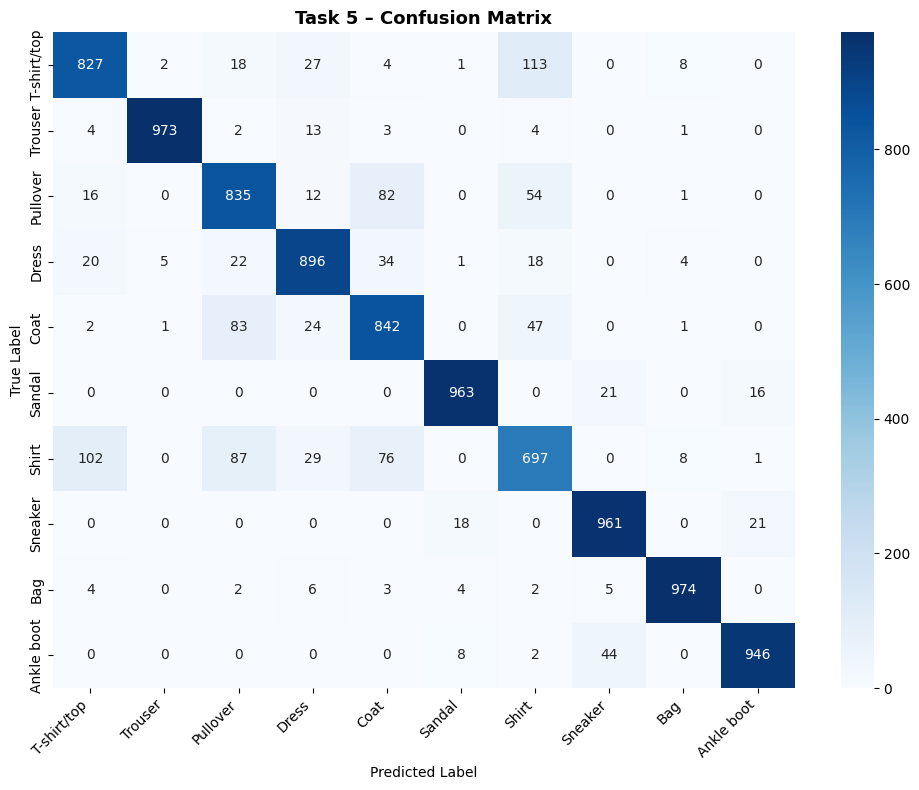

Saved: task5_confusion_matrix.png
Total misclassified: 1086 / 10000


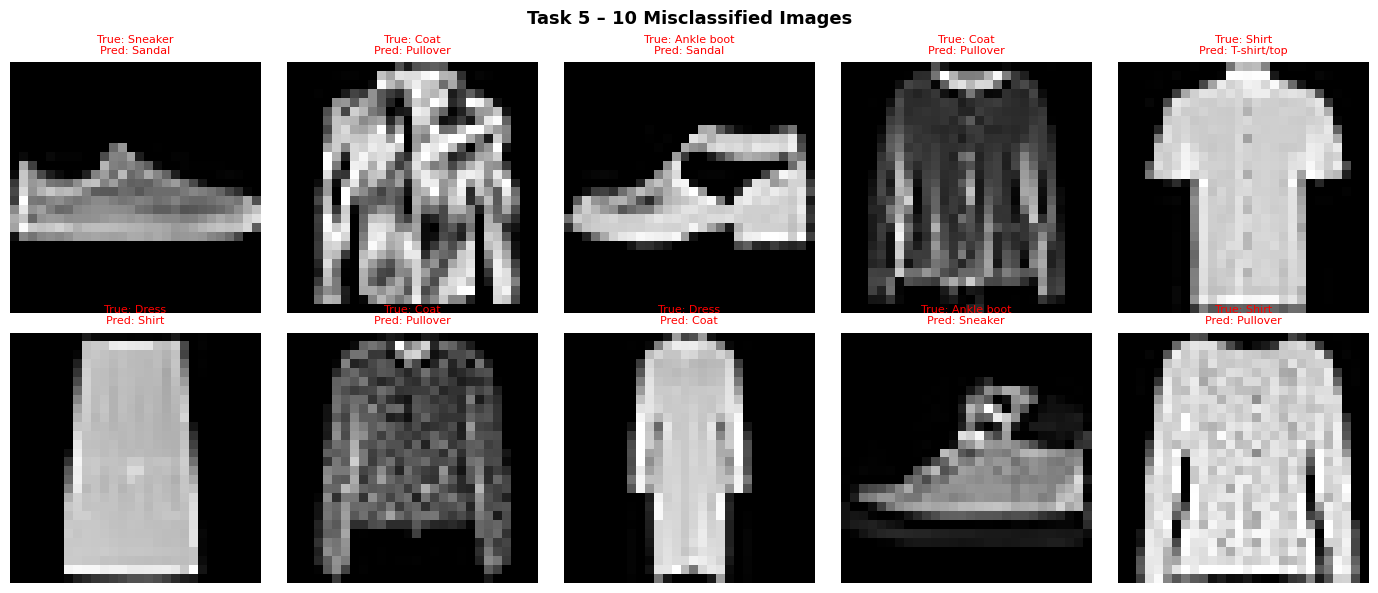

Saved: task5_misclassified.png

Top confused class pairs (True → Predicted):
  T-shirt/top     → Shirt            (113 times)
  Shirt           → T-shirt/top      (102 times)
  Shirt           → Pullover         (87 times)
  Coat            → Pullover         (83 times)
  Pullover        → Coat             (82 times)


In [ ]:
print("=" * 55)
print("Task 5 – Error Analysis on best model")
print("=" * 55)

# Use whichever achieved higher accuracy
best_model = model_c_bn if acc_bn >= t2_accs[best_idx] else best_model_t2
print(f"Using: {'Model C + BN' if acc_bn >= t2_accs[best_idx] else t2_labels[best_idx]}")

acc_best, all_preds, all_labels = evaluate_model(best_model, test_loader)
print(f"Test Accuracy: {acc_best:.4f}")

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Task 5 – Confusion Matrix", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("task5_confusion_matrix.png", dpi=120)
plt.show()
print("Saved: task5_confusion_matrix.png")

# 2. Misclassified images
misclassified_idx = np.where(all_preds != all_labels)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(all_labels)}")

# Gather original images from test_set
all_test_images = []
all_test_labels = []
for img, lbl in test_set:
    all_test_images.append(img)
    all_test_labels.append(lbl)

sample_wrong = misclassified_idx[:10]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Task 5 – 10 Misclassified Images", fontsize=13, fontweight="bold")
for ax, idx in zip(axes.flatten(), sample_wrong):
    img = all_test_images[idx].squeeze().numpy() * 0.5 + 0.5
    true_lbl = CLASS_NAMES[all_labels[idx]]
    pred_lbl = CLASS_NAMES[all_preds[idx]]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}", fontsize=8, color="red")
    ax.axis("off")
plt.tight_layout()
plt.savefig("task5_misclassified.png", dpi=120)
plt.show()
print("Saved: task5_misclassified.png")

# Most confused pairs
print("\nTop confused class pairs (True → Predicted):")
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
for _ in range(5):
    r, c = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
    print(f"  {CLASS_NAMES[r]:15s} → {CLASS_NAMES[c]:15s}  ({cm_no_diag[r,c]} times)")
    cm_no_diag[r, c] = 0

## TASK 6 - Model Efficiency Comparison


Task 6 – Model Efficiency Comparison Table
Model                                     Params   Test Acc   Train Time
------------------------------------------------------------------------
Model A (784→32→10)                       25,450     0.8678       153.6s
Model B (784→128→64→10)                  109,386     0.8727       160.6s
Model C (784→256→128→64→10)              242,762     0.8739       180.5s
Tiny Model (Task 3)                        3,190     0.8092            ~
Huge Model (Task 3)                    1,764,426     0.8837            ~
Model C + BatchNorm                      243,658     0.8914            ~


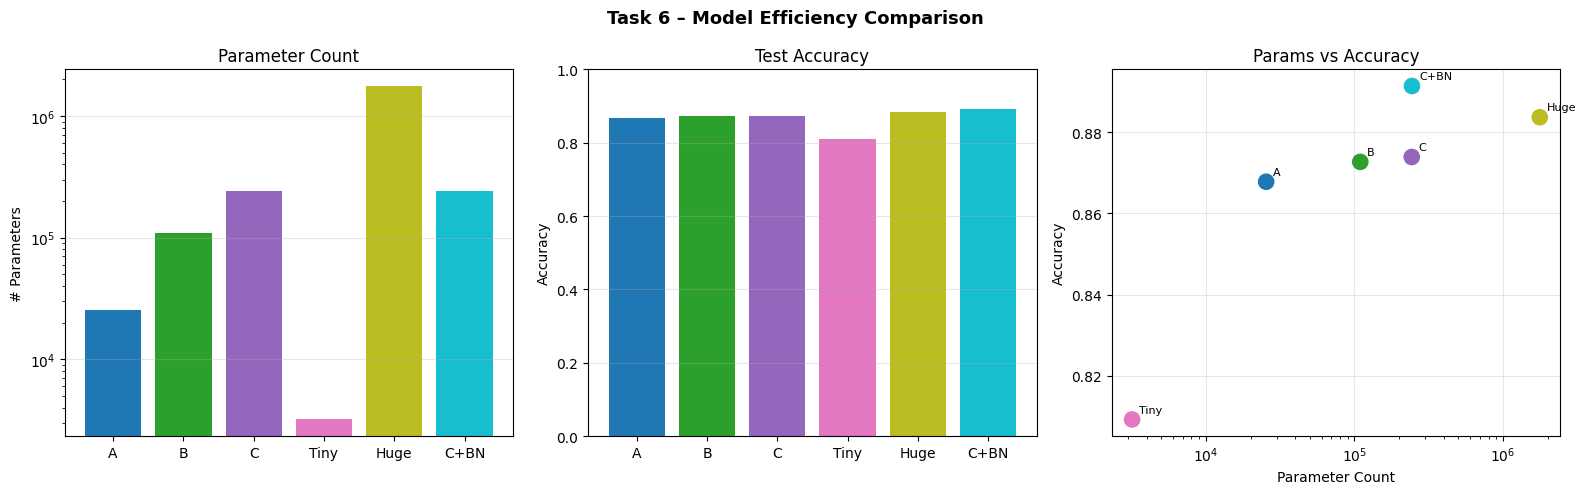

Saved: task6_efficiency.png


In [ ]:
print("=" * 55)
print("Task 6 – Model Efficiency Comparison Table")
print("=" * 55)

# Re-use already-trained results; re-time if needed
t3_models = [tiny_model, huge_model]
t3_labels = ["Tiny (784→4→10)", "Huge (784→…→10)"]
t3_accs   = [acc_tiny, acc_huge]

# Collect all models
all_model_names = (t2_labels +
                   ["Tiny Model (Task 3)", "Huge Model (Task 3)", "Model C + BatchNorm"])
all_model_refs  = t2_models + [tiny_model, huge_model, model_c_bn]
all_model_accs  = t2_accs   + [acc_tiny, acc_huge, acc_bn]
all_model_times = t2_times  + [0.0, 0.0, 0.0]   # timing already collected for T2; T3/T4 approx

all_params = [count_parameters(m) for m in all_model_refs]

# Print table
header = f"{'Model':<35} {'Params':>12} {'Test Acc':>10} {'Train Time':>12}"
print(header)
print("-" * len(header))
for name, params, acc, t in zip(all_model_names, all_params, all_model_accs, all_model_times):
    time_str = f"{t:.1f}s" if t > 0 else "~"
    print(f"{name:<35} {params:>12,} {acc:>10.4f} {time_str:>12}")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Task 6 – Model Efficiency Comparison", fontsize=13, fontweight="bold")

short_names = ["A", "B", "C", "Tiny", "Huge", "C+BN"]
colors = plt.cm.tab10(np.linspace(0, 1, len(short_names)))

axes[0].bar(short_names, all_params, color=colors)
axes[0].set_title("Parameter Count")
axes[0].set_ylabel("# Parameters")
axes[0].set_yscale("log")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(short_names, all_model_accs, color=colors)
axes[1].set_title("Test Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim([0, 1])
axes[1].grid(axis="y", alpha=0.3)

# Parameter count vs accuracy scatter
axes[2].scatter(all_params, all_model_accs, c=colors, s=120, zorder=3)
for i, name in enumerate(short_names):
    axes[2].annotate(name, (all_params[i], all_model_accs[i]),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[2].set_title("Params vs Accuracy")
axes[2].set_xlabel("Parameter Count")
axes[2].set_ylabel("Accuracy")
axes[2].set_xscale("log")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task6_efficiency.png", dpi=120)
plt.show()
print("Saved: task6_efficiency.png")

## BONUS - Gradient Stability Investigation


In [ ]:
class DeepMLP(nn.Module):
    """8-hidden-layer MLP, with or without BatchNorm."""
    def __init__(self, use_bn=False):
        super().__init__()
        layers = []
        in_dim = 784
        hidden = [256, 256, 256, 128, 128, 128, 64, 64]
        for h in hidden:
            layers.append(nn.Linear(in_dim, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)


def train_with_grad_tracking(model, train_loader, val_loader, epochs=10):
    """Train and record per-epoch mean absolute gradient norms."""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    history = {"train_loss": [], "val_loss": [], "val_acc": [],
               "grad_norms": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, epoch_grads = 0.0, []

        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            X = X.view(X.size(0), -1)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()

            # Record gradient norms for all Linear layers
            norms = [p.grad.abs().mean().item()
                     for p in model.parameters()
                     if p.grad is not None]
            epoch_grads.append(np.mean(norms))
            optimizer.step()
            running_loss += loss.item() * X.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                X = X.view(X.size(0), -1)
                out = model(X)
                val_loss += criterion(out, y).item() * X.size(0)
                correct  += (out.argmax(1) == y).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc   = correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["grad_norms"].append(np.mean(epoch_grads))

        if epoch % 2 == 0 or epoch == 1:
            print(f"  Epoch {epoch:02d}/{epochs}  Loss: {train_loss:.4f}  "
                  f"Val Acc: {val_acc:.4f}  Grad Norm: {np.mean(epoch_grads):.6f}")

    return history

Bonus – Deep MLP Gradient Stability (10 epochs)

── Deep MLP without BatchNorm (411,530 params) ──
  Epoch 01/10  Loss: 0.8408  Val Acc: 0.8094  Grad Norm: 0.006806
  Epoch 02/10  Loss: 0.4952  Val Acc: 0.8338  Grad Norm: 0.004354
  Epoch 04/10  Loss: 0.3773  Val Acc: 0.8577  Grad Norm: 0.003031
  Epoch 06/10  Loss: 0.3289  Val Acc: 0.8720  Grad Norm: 0.002465
  Epoch 08/10  Loss: 0.2999  Val Acc: 0.8806  Grad Norm: 0.002200
  Epoch 10/10  Loss: 0.2784  Val Acc: 0.8816  Grad Norm: 0.001998

── Deep MLP with BatchNorm (414,090 params) ──
  Epoch 01/10  Loss: 0.5870  Val Acc: 0.8487  Grad Norm: 0.002593
  Epoch 02/10  Loss: 0.4187  Val Acc: 0.8622  Grad Norm: 0.002090
  Epoch 04/10  Loss: 0.3357  Val Acc: 0.8771  Grad Norm: 0.001798
  Epoch 06/10  Loss: 0.3000  Val Acc: 0.8769  Grad Norm: 0.001696
  Epoch 08/10  Loss: 0.2719  Val Acc: 0.8868  Grad Norm: 0.001644
  Epoch 10/10  Loss: 0.2434  Val Acc: 0.8856  Grad Norm: 0.001594

Final Test Acc  No BN: 0.8741  |  With BN: 0.8831


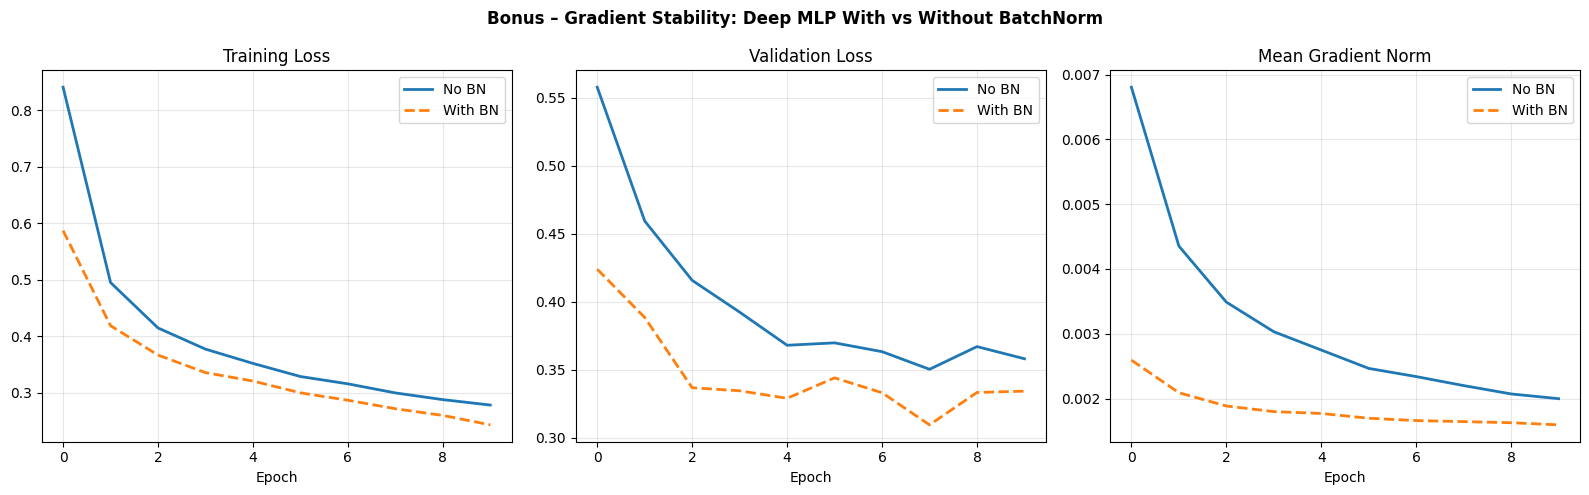

Saved: bonus_gradient_stability.png


In [ ]:
print("=" * 55)
print("Bonus – Deep MLP Gradient Stability (10 epochs)")
print("=" * 55)

deep_no_bn = DeepMLP(use_bn=False)
deep_with_bn = DeepMLP(use_bn=True)

print(f"\n── Deep MLP without BatchNorm ({count_parameters(deep_no_bn):,} params) ──")
hist_no_bn = train_with_grad_tracking(deep_no_bn, train_loader, val_loader, epochs=10)

print(f"\n── Deep MLP with BatchNorm ({count_parameters(deep_with_bn):,} params) ──")
hist_with_bn = train_with_grad_tracking(deep_with_bn, train_loader, val_loader, epochs=10)

acc_no_bn,   _, _ = evaluate_model(deep_no_bn,   test_loader)
acc_with_bn2, _, _ = evaluate_model(deep_with_bn, test_loader)
print(f"\nFinal Test Acc  No BN: {acc_no_bn:.4f}  |  With BN: {acc_with_bn2:.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Bonus – Gradient Stability: Deep MLP With vs Without BatchNorm",
             fontsize=12, fontweight="bold")

for metric, title, ax in zip(["train_loss", "val_loss", "grad_norms"],
                               ["Training Loss", "Validation Loss", "Mean Gradient Norm"],
                               axes):
    ax.plot(hist_no_bn[metric],   label="No BN",   linewidth=2)
    ax.plot(hist_with_bn[metric], label="With BN", linewidth=2, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bonus_gradient_stability.png", dpi=120)
plt.show()
print("Saved: bonus_gradient_stability.png")